==========Basic_explore_data===========

first top 5 row in data frame
    Hours_Studied  Exam_Score
0              1          18
1              2          22
2              3          33
3              4          35
4              5          40

 no of rows and columns of a data frame 
 (20, 2)

 basic information about the data frame 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours_Studied  20 non-null     int64
 1   Exam_Score     20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes

Missing Values:
Hours_Studied    0
Exam_Score       0
dtype: int64

==========showing_model_details===========

Coefficient: [4.82293987]
Intercept: 17.783964365256132

==========evaluating_model===========

trained data accuracy :0.9828408397898578 and  loss :3.3412119215453915
test data accuracy :0.9512845021695855 and  loss :6.6894876023545

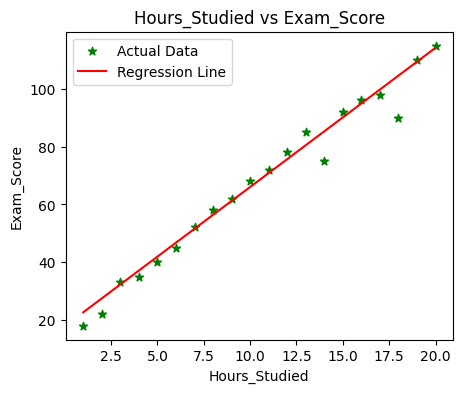

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                      11, 12, 13, 14, 15, 16, 17, 18, 19, 20],

    "Exam_Score": [18, 22, 33, 35, 40, 45, 52, 58, 62, 68,
                   72, 78, 85, 75, 92, 96, 98, 90, 110, 115]
}

class SimpleLinearRegressionProject:

  def __init__(self,data):
    self.df=pd.DataFrame(data)

  def explore_data(self):
    # basic information about our data Frame ...
    print("==========Basic_explore_data===========\n")
    print('first top 5 row in data frame\n',self.df.head())
    print(f'\n no of rows and columns of a data frame \n {self.df.shape}')
    print(f'\n basic information about the data frame \n ')
    self.df.info()
    print("\nMissing Values:")
    print(self.df.isnull().sum())

  def split_data(self):
    #Create X and y feature is x and target is y
    from sklearn.model_selection import train_test_split
    x=self.df[["Hours_Studied"]]
    y=self.df["Exam_Score"]
    self.xtrain,self.xtest,self.ytrain,self.ytest = train_test_split(x,y,test_size=0.3,random_state=42)

  def train_model(self):
    # train the model on available data........
    from sklearn.linear_model import LinearRegression
    self.lir=LinearRegression()
    self.model=self.lir.fit(self.xtrain,self.ytrain)

  def show_model_details(self):
    print("\n==========showing_model_details===========\n")
    print('Coefficient:',self.model.coef_) # m value
    print('Intercept:',self.model.intercept_) # c y= intercepter point

  def evaluate_model(self):
    print("\n==========evaluating_model===========\n")
    from sklearn.metrics import r2_score , root_mean_squared_error
    # predictions on trained data
    self.train_pred=self.model.predict(self.xtrain)
    # checking trained data accuracy and loss...
    trained_accuracy=r2_score(self.ytrain,self.train_pred)
    trained_loss=root_mean_squared_error(self.ytrain,self.train_pred)
    print(f'trained data accuracy :{trained_accuracy} and  loss :{trained_loss}')
    #predictions on test data
    self.test_pred=self.model.predict(self.xtest)
    # checking test data accuracy and loss ......
    test_accuracy=r2_score(self.ytest,self.test_pred)
    test_loss=root_mean_squared_error(self.ytest,self.test_pred)
    print(f'test data accuracy :{test_accuracy} and  loss :{test_loss}')


  def predict_score(self,hours):
    # user inputs and predictions...
    import numpy as np
    hours_data=np.array(hours).reshape(-1,1)
    self.predicted_results=self.model.predict(hours_data)
    return self.predicted_results

  def plot_regression_line(self):
    print("\n=========ploting===========\n")
    # display plot .......
    import matplotlib.pyplot as plt
    Hours_Studied_pred = self.model.predict(self.df['Hours_Studied'].to_numpy().reshape(-1,1))
    plt.figure(figsize=(5,4))
    plt.scatter(x=self.df["Hours_Studied"],y=self.df["Exam_Score"],color='g',marker="*",label="Actual Data")
    plt.plot(self.df["Hours_Studied"],Hours_Studied_pred ,color='r',label="Regression Line")
    plt.title('Hours_Studied vs Exam_Score')
    plt.xlabel('Hours_Studied')
    plt.ylabel('Exam_Score')
    plt.legend()
    plt.show()

# creating object and methods calling......
obj=SimpleLinearRegressionProject(data)
obj.explore_data()
obj.split_data()
obj.train_model()
obj.show_model_details()
obj.evaluate_model()
obj.predict_score([1,2,3,4,5,6,7,8,9,10,13])
r=obj.predicted_results
print(r)
obj.plot_regression_line()